# SVM: Finding the Widest Street Between Classes

We just watched logistic regression draw a line separating admitted from not-admitted. But that line was only *one* choice — infinitely many straight lines separate those same two groups correctly. Which one should we actually trust?

**The project:** reopen the same admissions data, draw a few other lines that also work, then let scikit-learn's SVM find the one line that stays as far as possible from both groups — the "widest street" between them. Then we'll push the idea further with a dataset no straight line can ever separate, and watch a kernel fix it.

**The plan:**
1. Reopen the admissions data and remember the logistic regression boundary.
2. Draw a few *other* valid separating lines by hand — see that the line isn't unique.
3. Let SVM find the widest-margin line, and see the support vectors that decide it.
4. Turn the `C` knob and watch the margin trade width for correctness.
5. Meet a dataset no straight line can separate, and fix it with a kernel.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC
from sklearn.datasets import make_circles

---
## 1. Reopening the admissions data

Same dataset, same two exam scores, same colours — admitted in red, not admitted in blue.

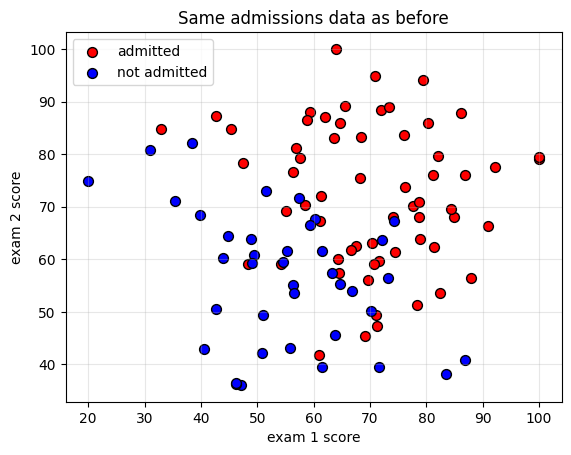

In [15]:
df = pd.read_csv(r"..\datasets\admissions.csv")

def plot_students(df):
    admitted = df[df["admitted"] == 1]
    rejected = df[df["admitted"] == 0]
    plt.scatter(admitted["exam1"], admitted["exam2"], c="red", label="admitted", edgecolor="k", s=50)
    plt.scatter(rejected["exam1"], rejected["exam2"], c="blue", label="not admitted", edgecolor="k", s=50)
    plt.xlabel("exam 1 score"); plt.ylabel("exam 2 score")
    plt.legend(); plt.grid(True, alpha=0.3)

plot_students(df)
plt.title("Same admissions data as before")
plt.show()

---
## 2. One line, or many?

Logistic regression drew one line through this data. But is that the *only* line that separates admitted from not-admitted correctly? Let's draw a few more by hand — pure guesses — and check whether they still work.

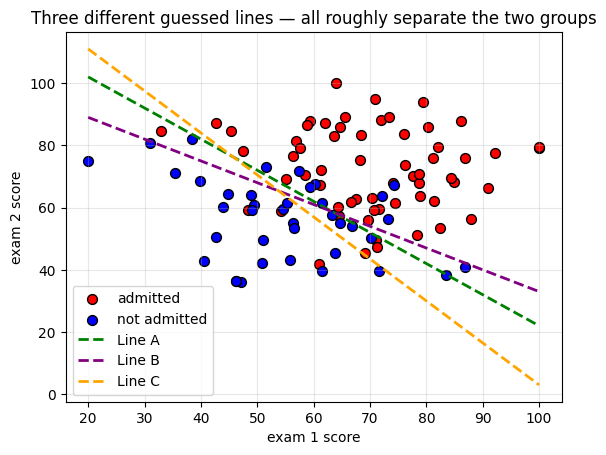

In [16]:
x_range = [df["exam1"].min(), df["exam1"].max()]

candidate_lines = [
    {"slope": -1.00, "intercept": 122, "label": "Line A", "color": "green"},
    {"slope": -0.70, "intercept": 103, "label": "Line B", "color": "purple"},
    {"slope": -1.35, "intercept": 138, "label": "Line C", "color": "orange"},
]

def line_points(slope, intercept, x_range):
    x_vals = np.array(x_range)
    y_vals = slope * x_vals + intercept
    return x_vals, y_vals

plot_students(df)
for line in candidate_lines:
    x_vals, y_vals = line_points(line["slope"], line["intercept"], x_range)
    plt.plot(x_vals, y_vals, "--", color=line["color"], linewidth=2, label=line["label"])
plt.title("Three different guessed lines — all roughly separate the two groups")
plt.legend()
plt.show()

In [17]:
def line_accuracy(slope, intercept, df):
    # predict "admitted" if the point sits above the line
    predicted = (df["exam2"] > slope * df["exam1"] + intercept).astype(int)
    return (predicted == df["admitted"]).mean()

for line in candidate_lines:
    acc = line_accuracy(line["slope"], line["intercept"], df)
    print(f"{line['label']}: accuracy = {acc:.1%}")

Line A: accuracy = 83.0%
Line B: accuracy = 84.0%
Line C: accuracy = 82.0%


All three lines "work" — none of them are crazy. But none of them were *found* by any training process, they were just guessed, and they don't even agree with each other. That's the problem: **guessing gives you *a* line, not the *best* line.** Which one would you actually trust to classify a brand new student correctly?

---
## 3. Letting SVM find the widest street

Instead of guessing, let's train a model whose entire job is to find the line that stays as far as possible from **both** groups at once — like finding the widest possible road between them with no students standing in it.

The edges of that road touch the nearest red point and the nearest blue point. Those touching points are called **support vectors** — they're the only points that decide where the road goes. Every other point could move further into its own territory and the road wouldn't shift at all.

In [18]:
X = df[["exam1", "exam2"]].values
y = df["admitted"].values

svm_linear = SVC(kernel="linear", C=1.0)   # C=1.0 is scikit-learn's default balance of width vs. correctness
svm_linear.fit(X, y)

print(f"Number of support vectors: {len(svm_linear.support_vectors_)}")
print(f"Training accuracy: {svm_linear.score(X, y):.1%}")

Number of support vectors: 43
Training accuracy: 82.0%


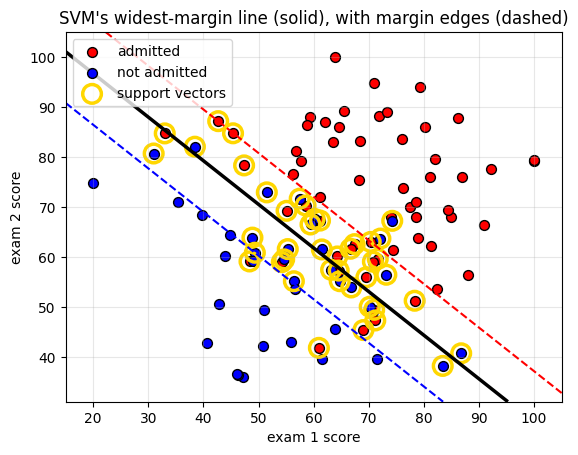

In [19]:
def plot_svm_boundary(model, df, X, title):
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    plot_students(df)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"],
                linestyles=["--", "-", "--"], linewidths=[1.5, 2.5, 1.5])
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                s=180, facecolors="none", edgecolors="gold", linewidths=2.5,
                label="support vectors")
    plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
    plt.title(title)
    plt.legend()

plot_svm_boundary(svm_linear, df, X, "SVM's widest-margin line (solid), with margin edges (dashed)")
plt.show()

The solid black line is SVM's boundary — the same shape of line logistic regression drew. The two dashed lines are the edges of the widest road SVM could fit without a student standing inside it. The gold-circled points are the support vectors: nudge any of them and the road tilts; nudge anything else and nothing changes at all.

---
## 4. Turning the `C` knob

Real data is rarely perfectly separable — sometimes there's no straight road wide enough to keep every single student outside of it. `C` is the setting that decides how strict SVM should be about that:

- **Low `C`** → SVM tolerates a few students standing inside the road, in exchange for a **wider**, more stable street.
- **High `C`** → SVM insists on getting (almost) everyone right, even if the street has to get **narrow** and twitchy to do it.

Same trade-off as an overly flexible polynomial fitting the training data too tightly — a narrow, twitchy street is a model that may not generalize as well to a new student.

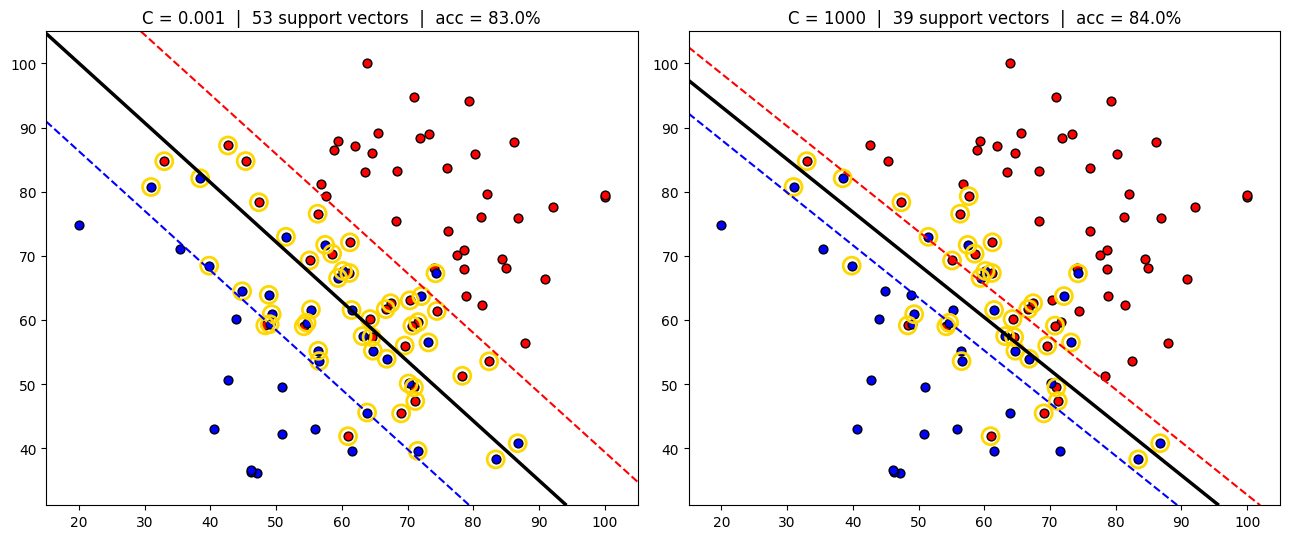

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, C_value in zip(axes, [0.001, 1000]):
    model = SVC(kernel="linear", C=C_value)
    model.fit(X, y)

    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    admitted = df[df.admitted == 1]; rejected = df[df.admitted == 0]
    ax.scatter(admitted.exam1, admitted.exam2, c="red", edgecolor="k", s=40)
    ax.scatter(rejected.exam1, rejected.exam2, c="blue", edgecolor="k", s=40)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["blue", "black", "red"],
               linestyles=["--", "-", "--"], linewidths=[1.5, 2.5, 1.5])
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=150, facecolors="none", edgecolors="gold", linewidths=2)
    ax.set_title(f"C = {C_value}  |  {len(model.support_vectors_)} support vectors  |  acc = {model.score(X, y):.1%}")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

Watch the support-vector count and the road width move in opposite directions as `C` changes. Neither setting is "wrong" — it's the same bias-variance conversation from linear and polynomial regression, just wearing a different name.

---
## 5. A shape no straight line can separate

Everything so far has been a straight-line problem. Here's a dataset where that assumption breaks completely: one class forms a ring around the other.

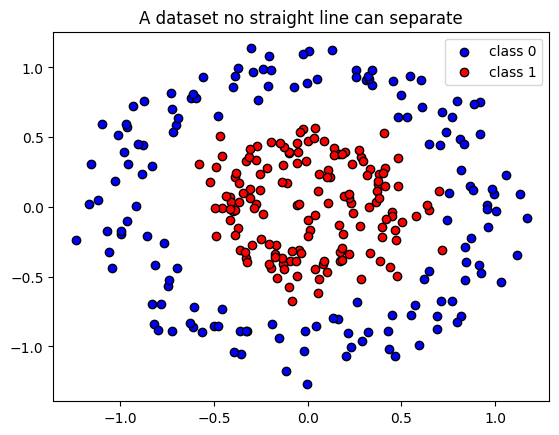

In [20]:
X_ring, y_ring = make_circles(n_samples=300, factor=0.4, noise=0.12, random_state=42)

plt.figure()
plt.scatter(X_ring[y_ring == 0, 0], X_ring[y_ring == 0, 1], c="blue", edgecolor="k", label="class 0")
plt.scatter(X_ring[y_ring == 1, 0], X_ring[y_ring == 1, 1], c="red", edgecolor="k", label="class 1")
plt.title("A dataset no straight line can separate")
plt.legend()
plt.show()

Try to imagine any straight line that puts every red point on one side and every blue point on the other. There isn't one — one class completely surrounds the other. Let's see what a linear SVM does here, then try a **kernel**.

A kernel lets SVM implicitly work in a higher-dimensional space where the data *does* become separable by a straight cut, then hands back a curved boundary once we look at it in the original 2D space. We don't have to compute that higher-dimensional space ourselves — the kernel does it for us. Let's just compare the results.

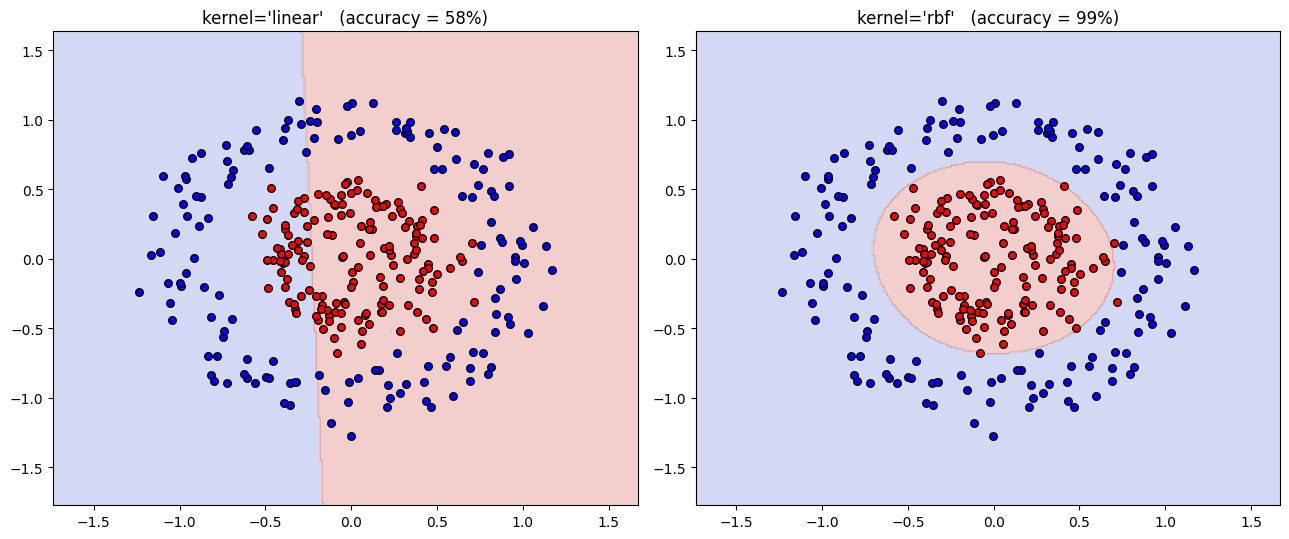

In [12]:
def plot_decision_regions(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", edgecolor="k", s=30)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", edgecolor="k", s=30)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

linear_model = SVC(kernel="linear").fit(X_ring, y_ring)
rbf_model = SVC(kernel="rbf").fit(X_ring, y_ring)

plot_decision_regions(linear_model, X_ring, y_ring, axes[0],
                       f"kernel='linear'   (accuracy = {linear_model.score(X_ring, y_ring):.0%})")
plot_decision_regions(rbf_model, X_ring, y_ring, axes[1],
                       f"kernel='rbf'   (accuracy = {rbf_model.score(X_ring, y_ring):.0%})")
plt.tight_layout()
plt.show()

The linear kernel does the best any straight line possibly could here — which isn't very good, because no straight line was ever going to work. The `rbf` kernel wraps a curved boundary right around the inner ring. Same `SVC` class, same `.fit()` call — the only thing that changed is which kernel does the lifting.

---
## 6. Bonus: why the "lift" actually works

Here's the trampoline picture made literal. Give every point a third coordinate — its distance from the center, `x² + y²` — and plot all three dimensions at once.

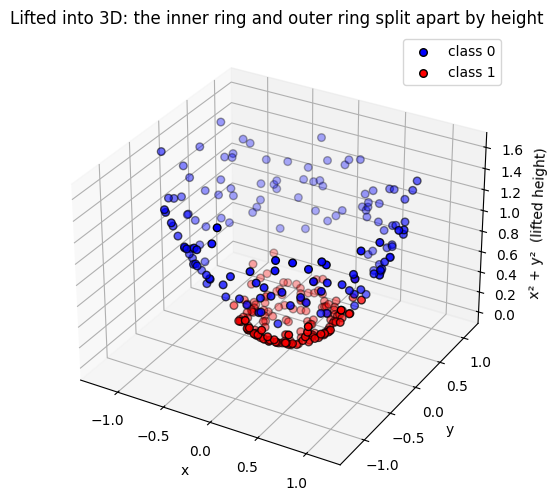

In [21]:
z_lift = X_ring[:, 0]**2 + X_ring[:, 1]**2

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_ring[y_ring == 0, 0], X_ring[y_ring == 0, 1], z_lift[y_ring == 0],
           c="blue", edgecolor="k", s=30, label="class 0")
ax.scatter(X_ring[y_ring == 1, 0], X_ring[y_ring == 1, 1], z_lift[y_ring == 1],
           c="red", edgecolor="k", s=30, label="class 1")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("x² + y²  (lifted height)")
ax.set_title("Lifted into 3D: the inner ring and outer ring split apart by height")
ax.legend()
plt.show()

The ring closer to the center lifts to a lower height; the ring further out lifts higher. Once height is on the table, a single **flat plane** sliced through the middle separates them perfectly. Flatten that plane back down into the original 2D view, and it reappears as the curved circular boundary the `rbf` kernel found. That's the whole trick: **lift until a straight cut works, then look at the shadow it casts back in the original space.**

---
## Summary

- Many lines can separate two classes correctly. Logistic regression finds one via log loss; SVM specifically searches for the **widest-margin** line.
- Only the closest points — the **support vectors** — decide where that line goes. Every other point could move deeper into its own territory with zero effect on the boundary.
- **`C`** trades margin width for strict correctness: low `C` tolerates a few points inside the margin for a wider, more stable street; high `C` insists on tighter separation at the cost of a narrower one.
- Not every dataset is linearly separable. A **kernel** implicitly lifts the data into a higher dimension where a straight cut becomes possible, then hands back a curved boundary in the space we started in.
- The underlying score is still the familiar `z = w·x + b` — SVM just trains it toward a different goal, and optionally in a different feature space.